In [72]:
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\Tony
[nltk_data]     Medhat\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Tony
[nltk_data]     Medhat\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Tony
[nltk_data]     Medhat\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [73]:
import re
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

import contractions

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight

from collections import Counter

In [74]:
GLOBAL_SEED = 42
NUMPY_PRECISION = 3

def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)

np.set_printoptions(precision=NUMPY_PRECISION)
set_global_seed(GLOBAL_SEED)

print(f"Global Seed: {GLOBAL_SEED}")
print(f"Numpy Precision: {NUMPY_PRECISION}")

print(f"\nTensorflow Version: {tf.__version__}")
print(f"Tensorflow Cuda Enabled: {tf.test.is_built_with_cuda()}")
print(f"Tensorflow GPUs: {tf.config.list_physical_devices('GPU')}")

Global Seed: 42
Numpy Precision: 3

Tensorflow Version: 2.10.1
Tensorflow Cuda Enabled: True
Tensorflow GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [75]:
def remove_stopwords(text):
    SENTIMENT_CRITICAL_WORDS = {
        # Negations
        'not', 'no', 'never',
        'neither', 'nor', 'none', 'nobody',
        'nothing', 'nowhere', 'hardly', 'scarcely', 'barely',

        # Intensifiers
        'very', 'really', 'absolutely', 'completely', 'extremely',
        'quite', 'rather', 'pretty', 'too', 'enough',

        # Negation indicators
        'but', 'however', 'although', 'though', 'yet', 'because',

        # Modal verbs (express certainty/doubt)
        'should', 'would', 'wouldn', "wouldn't",
        'could', 'might', 'mightn', "mightn't", 'may', 'must',
        "mustn't", 'mustn',
        'can', 'cannot', "can't", 'will', "won't", 'won',
        'couldn', "couldn't", 'don', "don't",
        'should', "should've", 'shouldn', "shouldn't",
    }
    STOPWORDS = set(stopwords.words('english'))

    tokens = word_tokenize(text)
    filtered_stopwords_subset = STOPWORDS - SENTIMENT_CRITICAL_WORDS
    filtered_tokens = [word for word in tokens if word not in filtered_stopwords_subset]

    return ' '.join(filtered_tokens)


def stemming(text):
    tokens = word_tokenize(text)
    stemmer = SnowballStemmer("english")
    stemmed_tokens = [stemmer.stem(token) for token in tokens]

    return ' '.join(stemmed_tokens)


def handle_emotes(text):
    return re.sub(r'(:\s?\)|:-\s?\)|:\s?D|:-\s?D|:\s?\(|:-\s?\(|;-\s?\)|;\s?\)|:P|:-P|:-O|:O|<3)', '', text)


def remove_noisy_punctuations(text):
    return re.sub(r'[\"#$%&\'()*+\-\/:;<=>@\[\\\]^_`{|}~]', '', text)


def remove_redundant_punctuation(text):
    return re.sub(r'([!\"#$%&\'()*+,\-.\/:;<=>?@\[\\\]^_`{|}~ ])\1+', r'\1', text)


def preprocess_text(text, use_stemming=False, include_stopwords=False):
    text = text.lower()

    # Strip Urls
    text = re.sub(r'http\S+', '', text)

    # Strip HTML Tags
    text = re.sub(r'<.*?>', '', text)

    # Expand Contractions (can't --> can not)
    text = contractions.fix(text)

    # Remove Numbers
    text = re.sub(r'\d+', '', text)

    # Note(Tony): TextVectorization as can remove punctuations.
    text = handle_emotes(text)
    text = remove_noisy_punctuations(text)
    text = remove_redundant_punctuation(text)

    if not include_stopwords:
        text = remove_stopwords(text)

    if use_stemming:
        text = stemming(text)

    # Remove extra whitespaces
    text = ' '.join(text.split())

    return text

Class Distribution: review
Very good    2469
Excellent    2335
Good         1024
Bad           648
Very bad      524
Name: count, dtype: int64
Dataset Shape: (7000, 3)


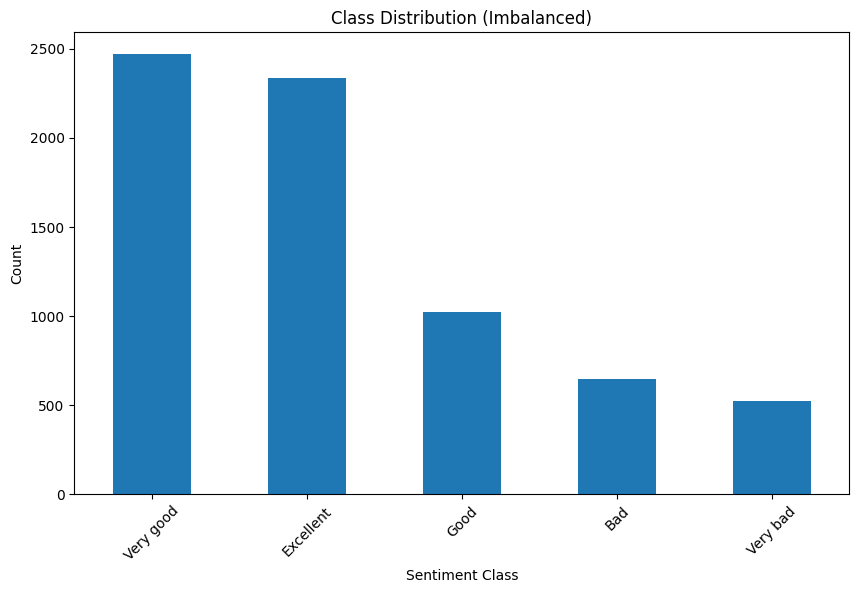

In [76]:
df = pd.read_csv('../data/train.csv', encoding='latin-1')

print(f"Class Distribution: {df['review'].value_counts()}")
print(f"Dataset Shape: {df.shape}")

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
df['review'].value_counts().plot(ax=ax, kind='bar')
ax.set_title("Class Distribution (Imbalanced)")
ax.set_xlabel("Sentiment Class")
ax.set_ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [77]:
X_raw = df['text'].astype(str).values

# Encode `review` column
class_label_encoder = LabelEncoder()
y_encoded = class_label_encoder.fit_transform(df['review'])

CLASS_LABELS = class_label_encoder.classes_
NUM_CLASSES = len(class_label_encoder.classes_)

print(f"Number of classes: {NUM_CLASSES}")
print(f"Class mapping: {dict(enumerate(class_label_encoder.classes_))}")

Number of classes: 5
Class mapping: {0: 'Bad', 1: 'Excellent', 2: 'Good', 3: 'Very bad', 4: 'Very good'}


Train size     : 5652
Validation size: 298
Test size      : 1050


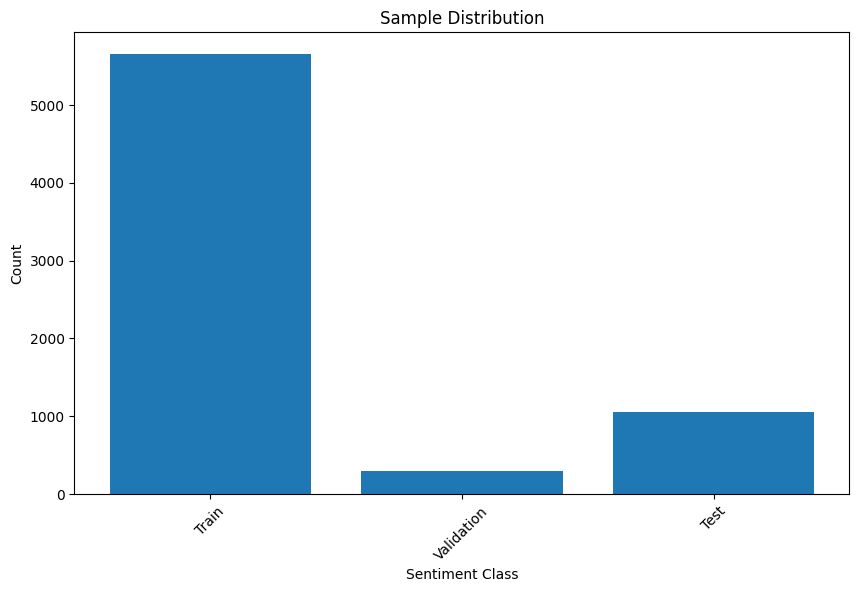

In [78]:
TEXT_SPLIT_SIZE = 0.15
VALIDATION_SPLIT_SIZE = 0.05

# Split data into 80% train, 5% validation, and 15% test.
X_train_validation_raw, X_test_raw, y_train_validation, y_test = train_test_split(X_raw, y_encoded, test_size=TEXT_SPLIT_SIZE, stratify=y_encoded, random_state=GLOBAL_SEED)
X_train_raw, X_validation_raw, y_train, y_validation = train_test_split(X_train_validation_raw, y_train_validation, test_size=VALIDATION_SPLIT_SIZE, stratify=y_train_validation, random_state=GLOBAL_SEED)

print(f"Train size     : {len(X_train_raw)}")
print(f"Validation size: {len(X_validation_raw)}")
print(f"Test size      : {len(X_test_raw)}")

# Data for bar chart
labels = ["Train", "Validation", "Test"]
sizes  = [len(X_train_raw), len(X_validation_raw), len(X_test_raw)]

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.bar(labels, sizes)
ax.set_title("Sample Distribution")
ax.set_xlabel("Sentiment Class")
ax.set_ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [79]:
X_train_cleaned      = np.array([ preprocess_text(text) for text in X_train_raw ])
X_validation_cleaned = np.array([ preprocess_text(text) for text in X_validation_raw])
X_test_cleaned       = np.array([ preprocess_text(text) for text in X_test_raw ])

X_train_validation_cleaned = np.array([preprocess_text(text) for text in X_train_validation_raw])

In [80]:
# Display the text after cleanup, easier for debugging
pd.DataFrame(X_train_cleaned[50:], columns=["text"])

,text
0,eaten quite yogis grills since started opening...
1,many great things say place begin . house marg...
2,"pretty ok place , right thick , saw separate a..."
3,would normally give place stars regular year ....
4,"facility very clean got quick . however , staf..."
...,...
5597,wow . reading reviews makes uofp sound like te...
5598,goto spot manipedis brow waxing . bangup job p...
5599,"nice facilities , nice ac , but two fatal flaw..."
5600,fav mexican place far ! make delicious chicken...


In [81]:
UNIQUE_LABEL_CLASSES = np.unique(y_train_validation)

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=UNIQUE_LABEL_CLASSES,
    y=y_train_validation
)
class_weights = dict(zip(UNIQUE_LABEL_CLASSES, weights))

print("Class weights:")
for label, weight in zip(class_label_encoder.classes_, weights):
    print(f"  {label}: {weight:.3f}")

Class weights:
  Bad: 2.160
  Excellent: 0.599
  Good: 1.368
  Very bad: 2.674
  Very good: 0.567


In [107]:
text_lengths = np.array([len(text.split()) for text in X_train_cleaned])

median_length = np.median(text_lengths)
max_length = np.max(text_lengths)

# Choose a percentile cutoff (90%)
OPTIMAL_PERCENTILE = 0.9

OPTIMAL_SEQUENCE_LENGTH = int(np.percentile(text_lengths, OPTIMAL_PERCENTILE * 100))

all_tokens = [token for text in X_train_cleaned for token in text.split()]
token_counts = Counter(all_tokens)
total_tokens = sum(token_counts.values())

# cumulative coverage
sorted_counts = [count for _, count in token_counts.most_common()]
cumsum = np.cumsum(sorted_counts)
coverage = cumsum / total_tokens

OPTIMAL_VOCAB_SIZE = np.searchsorted(coverage, OPTIMAL_PERCENTILE) + 1

print(f"Sequence length ({OPTIMAL_PERCENTILE} percentile): {OPTIMAL_SEQUENCE_LENGTH} tokens")
print(f"Median text length: {median_length:.2f} tokens")
print(f"Max text length: {max_length} tokens")
print(f"Vocabulary size (0.95 percentile): {OPTIMAL_VOCAB_SIZE}")
print(f"Actual vocabulary size: {len(token_counts)}")

Sequence length (0.9 percentile): 172 tokens
Median text length: 65.00 tokens
Max text length: 625 tokens
Vocabulary size (0.95 percentile): 3878
Actual vocabulary size: 25745


In [108]:
VOCAB_SIZE = 15000
MAX_SEQUENCE_LENGTH = 250
N_GRAM = 2

text_vec_layer = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_sequence_length=MAX_SEQUENCE_LENGTH,
    pad_to_max_tokens=True,
    ngrams=N_GRAM,
    standardize=None,
)
text_vec_layer.adapt(X_train_validation_cleaned)

# Display the text after cleanup, easier for debugging
pd.DataFrame(text_vec_layer.get_vocabulary(), columns=["Frequent Tokens"])

,Frequent Tokens
0,
1,[UNK]
2,.
3,","
4,not
...,...
14995,driveins
14996,drive !
14997,drinks dinner
14998,drink water


In [109]:
def evaluate_model(model, history, X, y):
    fig, axes = plt.subplots(1, 2, figsize=(10, 6))

    if history is not None:
        history_dict = history.history
        train_accuracy = history_dict['accuracy']
        validation_accuracy = history_dict['val_accuracy']

        epochs = range(1, len(train_accuracy) + 1)

        axes[0].plot(epochs, train_accuracy, 'r', label='Training acc')
        axes[0].plot(epochs, validation_accuracy, 'b', label='Validation acc')
        axes[0].set_title('Training and validation accuracy')
        axes[0].set_xlabel('Epochs')
        axes[0].set_ylabel('Accuracy')
        axes[0].legend(loc='lower right')

    y_pred_probs = model.predict(X)
    y_pred       = np.argmax(y_pred_probs, axis=1)
    test_accuracy = accuracy_score(y, y_pred)
    print(f"Test accuracy: {test_accuracy:.4f}")

    cm   = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_label_encoder.classes_)
    disp.plot(cmap=plt.cm.Reds, ax=axes[1], colorbar=False)

    plt.tight_layout()
    plt.show()

In [110]:
def KFoldTrain(model_func, X, y, epochs=5, class_weight=None, callbacks=None, batch_size=32, n_folds=5, shuffle=True):
    kfold = KFold(n_splits=n_folds, shuffle=shuffle, random_state=GLOBAL_SEED)

    history = None
    best_metric = np.inf
    best_model = None

    for fold, (index_train, index_test) in enumerate(kfold.split(X, y), 1):
        model = model_func(print_summary = (fold == 1))

        print(f"\n===== Fold {fold} / {n_folds} =====")

        history = model.fit(
            X[index_train],
            y[index_train],
            validation_data=(X[index_test], y[index_test]),
            epochs=epochs,
            batch_size=batch_size,
            class_weight=class_weight,
            callbacks=callbacks,
            verbose=2,
        )

        val_loss = history.history["val_loss"][-1]

        if val_loss < best_metric:
            best_metric = val_loss
            best_model = model

    return best_model, history

In [112]:
BATCH_SIZE    = 64
EMBEDDING_DIM = 128

# Callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)
reduce_lr      = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)

Model: "single_layer_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_vectorization_3 (TextV  (None, 250)              0         
 ectorization)                                                   
                                                                 
 embedding_81 (Embedding)    (None, 250, 128)          1920000   
                                                                 
 global_average_pooling1d_67  (None, 128)              0         
  (GlobalAveragePooling1D)                                       
                                                                 
 dense_160 (Dense)           (None, 5)                 645       
                                                                 
Total params: 1,920,645
Trainable params: 1,920,645
Non-trainable params: 0
_________________________________________________________________

===== Fold 1 / 5 =====
Epoch 1/15
75/

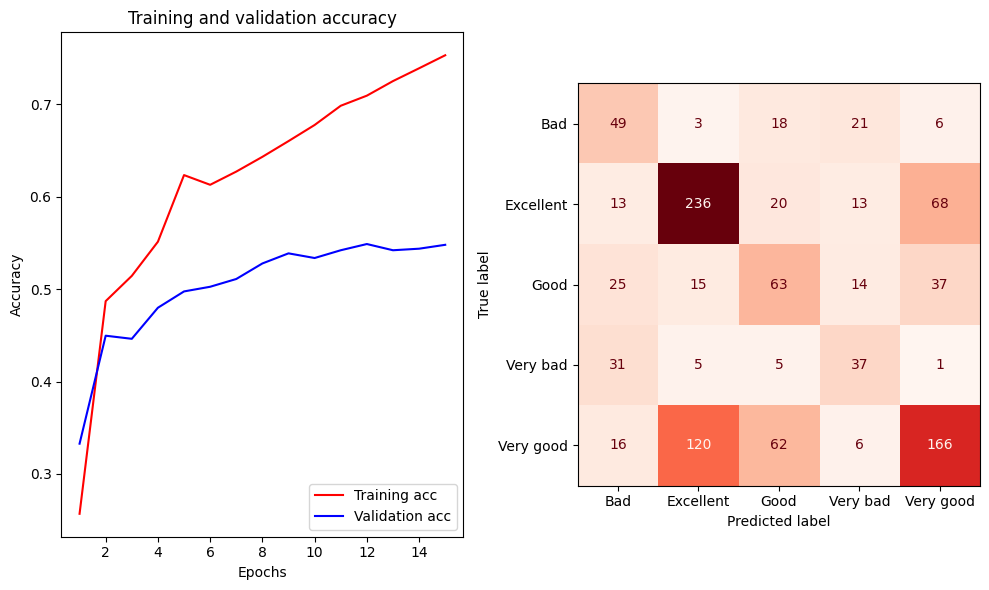

In [113]:
# Single Layer

EPOCHS = 15
LEARNING_RATE = 0.0005
L2_NORM = 0.001

def create_single_layer_model(print_summary=True):
    single_layer_model = tf.keras.Sequential(
        [
            text_vec_layer,
            tf.keras.layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, mask_zero=True),
            tf.keras.layers.GlobalAveragePooling1D(),
            tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(L2_NORM))
        ],
        name="single_layer_model",
    )
    single_layer_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    if print_summary:
        single_layer_model.summary()
p
    return single_layer_model

single_layer_model, history = KFoldTrain(
    create_single_layer_model,
    X_train_validation_cleaned,
    y_train_validation,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr],
)

evaluate_model(single_layer_model, history, X_test_cleaned, y_test)

Model: "multi_layer_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_vectorization_3 (TextV  (None, 250)              0         
 ectorization)                                                   
                                                                 
 embedding_107 (Embedding)   (None, 250, 128)          1920000   
                                                                 
 global_average_pooling1d_88  (None, 128)              0         
  (GlobalAveragePooling1D)                                       
                                                                 
 dense_207 (Dense)           (None, 64)                8256      
                                                                 
 dropout_65 (Dropout)        (None, 64)                0         
                                                                 
 dense_208 (Dense)           (None, 5)           

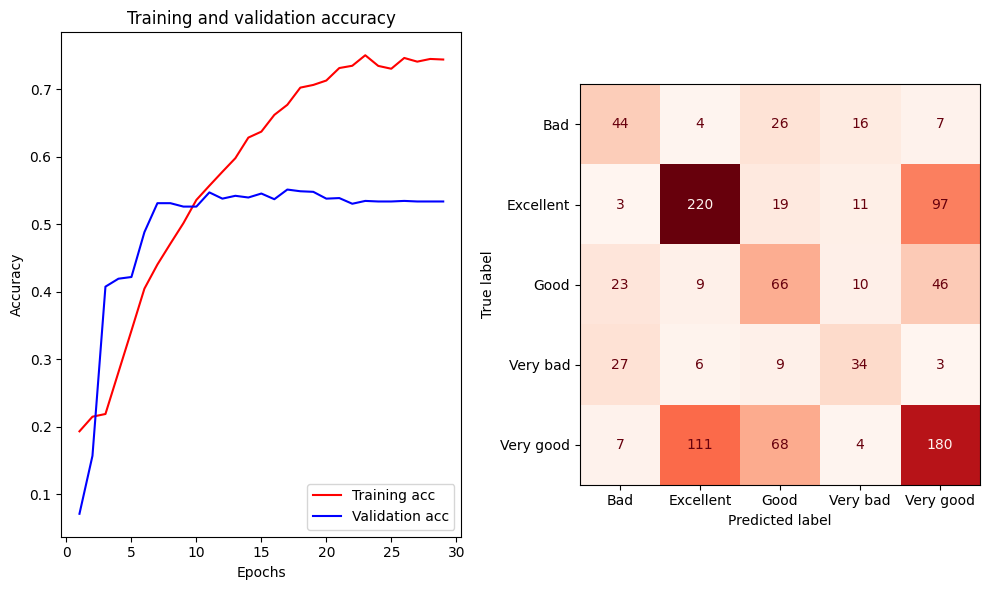

In [123]:
# Multi Layer

HIDDEN_DIM = 64
EPOCHS = 30
DROPOUT_RATE = 0.2
LEARNING_RATE = 0.001
L2_NORM = 0.001

def create_multi_layer_model(print_summary=True):
    multi_layer_model = tf.keras.Sequential(
        [
            text_vec_layer,
            tf.keras.layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, mask_zero=True, trainable=True),
            tf.keras.layers.GlobalAveragePooling1D(),
            tf.keras.layers.Dense(HIDDEN_DIM, activation='sigmoid', kernel_regularizer=tf.keras.regularizers.l2(L2_NORM)),
            # tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Dropout(DROPOUT_RATE),
            tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(L2_NORM))
        ],
        name="multi_layer_model",
    )
    multi_layer_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    if print_summary:
        multi_layer_model.summary()

    return multi_layer_model

multi_layer_model, history = KFoldTrain(
    create_multi_layer_model,
    X_train_validation_cleaned,
    y_train_validation,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr],
)

evaluate_model(multi_layer_model, history, X_test_cleaned, y_test)

Model: "cnn_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_vectorization_3 (TextV  (None, 250)              0         
 ectorization)                                                   
                                                                 
 embedding_112 (Embedding)   (None, 250, 128)          1920000   
                                                                 
 conv1d_8 (Conv1D)           (None, 246, 20)           12820     
                                                                 
 global_average_pooling1d_93  (None, 20)               0         
  (GlobalAveragePooling1D)                                       
                                                                 
 dense_217 (Dense)           (None, 64)                1344      
                                                                 
 dropout_70 (Dropout)        (None, 64)                0 

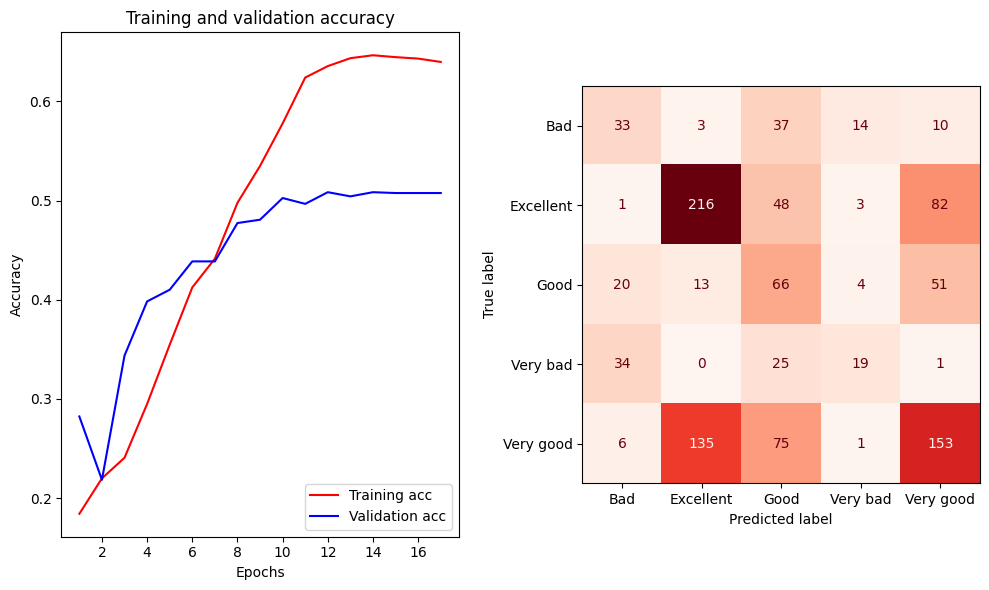

In [124]:
# CNN

HIDDEN_DIM = 64
N_FILTERS = 20
FILTER_SIZE = 5
EPOCHS = 20
LEARNING_RATE = 0.001
DROPOUT_RATE = 0.5
L2_NORM = 0.001

def create_cnn_model(print_summary=True):
    cnn_model = tf.keras.Sequential(
        [
            text_vec_layer,
            tf.keras.layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, mask_zero=True),
            tf.keras.layers.Conv1D(filters=N_FILTERS, kernel_size=FILTER_SIZE),
            tf.keras.layers.GlobalAveragePooling1D(),
            tf.keras.layers.Dense(HIDDEN_DIM, activation='sigmoid', kernel_regularizer=tf.keras.regularizers.l2(L2_NORM)),
            tf.keras.layers.Dropout(DROPOUT_RATE),
            tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(L2_NORM))
        ],
        name="cnn_model",
    )
    cnn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    if print_summary:
        cnn_model.summary()

    return cnn_model

cnn_model, history = KFoldTrain(
    create_cnn_model,
    X_train_validation_cleaned,
    y_train_validation,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr],
)

evaluate_model(cnn_model, history, X_test_cleaned, y_test)

Model: "rnn_ltsm_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_vectorization_3 (TextV  (None, 250)              0         
 ectorization)                                                   
                                                                 
 embedding_117 (Embedding)   (None, 250, 128)          1920000   
                                                                 
 lstm_9 (LSTM)               (None, 32)                20608     
                                                                 
 dropout_75 (Dropout)        (None, 32)                0         
                                                                 
 dense_227 (Dense)           (None, 5)                 165       
                                                                 
Total params: 1,940,773
Trainable params: 1,940,773
Non-trainable params: 0
__________________________________________

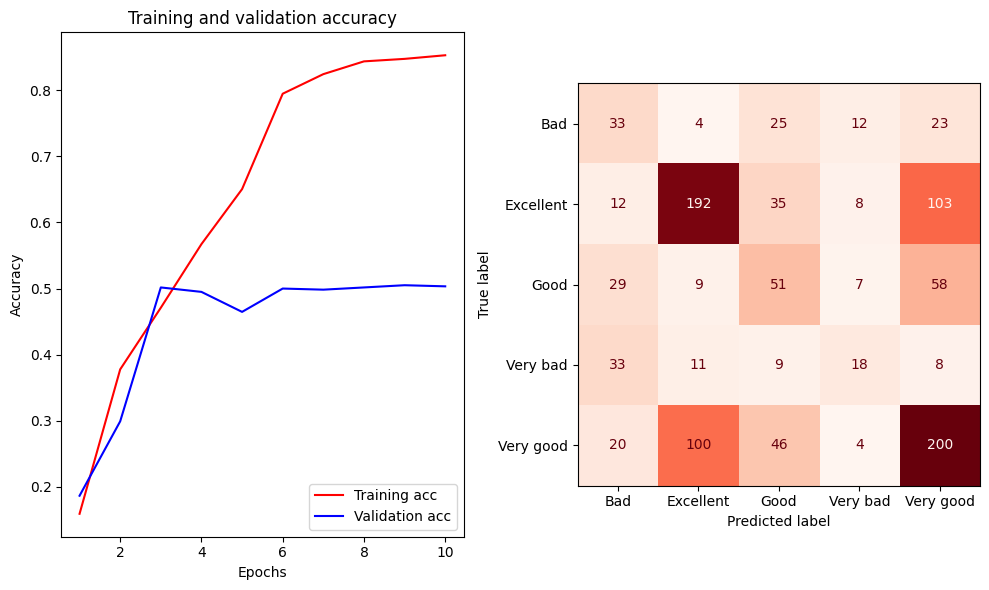

In [125]:
# RNN using Long Term Short Memory (LTSM)

HIDDEN_DIM = 32
EPOCHS = 10
LEARNING_RATE = 0.001
DROPOUT_RATE = 0.5

def create_rnn_model(print_summary=True):
    rnn_model = tf.keras.Sequential(
        [
            text_vec_layer,
            tf.keras.layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, mask_zero=True),
            tf.keras.layers.LSTM(HIDDEN_DIM, dropout=DROPOUT_RATE),
            tf.keras.layers.Dropout(DROPOUT_RATE),
            tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(L2_NORM))
        ],
        name="rnn_ltsm_model",
    )
    rnn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    if print_summary:
        rnn_model.summary()

    return rnn_model

rnn_model, history = KFoldTrain(
    create_rnn_model,
    X_train_validation_cleaned,
    y_train_validation,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr],
)

evaluate_model(rnn_model, history, X_test_cleaned, y_test)

Epoch 1/10
89/89 - 5s - loss: 1.6352 - accuracy: 0.1996 - val_loss: 1.6300 - val_accuracy: 0.2349 - lr: 0.0010 - 5s/epoch - 53ms/step
Epoch 2/10
89/89 - 2s - loss: 1.6008 - accuracy: 0.2502 - val_loss: 1.6577 - val_accuracy: 0.1007 - lr: 0.0010 - 2s/epoch - 24ms/step
Epoch 3/10
89/89 - 2s - loss: 1.4215 - accuracy: 0.3634 - val_loss: 1.1608 - val_accuracy: 0.4362 - lr: 0.0010 - 2s/epoch - 25ms/step
Epoch 4/10
89/89 - 2s - loss: 1.0960 - accuracy: 0.4942 - val_loss: 1.1411 - val_accuracy: 0.4966 - lr: 0.0010 - 2s/epoch - 24ms/step
Epoch 5/10
89/89 - 2s - loss: 0.8001 - accuracy: 0.6210 - val_loss: 1.4163 - val_accuracy: 0.3859 - lr: 0.0010 - 2s/epoch - 23ms/step
Epoch 6/10
89/89 - 2s - loss: 0.5564 - accuracy: 0.7606 - val_loss: 1.6665 - val_accuracy: 0.4329 - lr: 0.0010 - 2s/epoch - 24ms/step
Epoch 7/10
89/89 - 2s - loss: 0.2914 - accuracy: 0.8956 - val_loss: 1.7316 - val_accuracy: 0.4832 - lr: 2.0000e-04 - 2s/epoch - 23ms/step
Epoch 8/10
89/89 - 2s - loss: 0.1861 - accuracy: 0.9407 - 

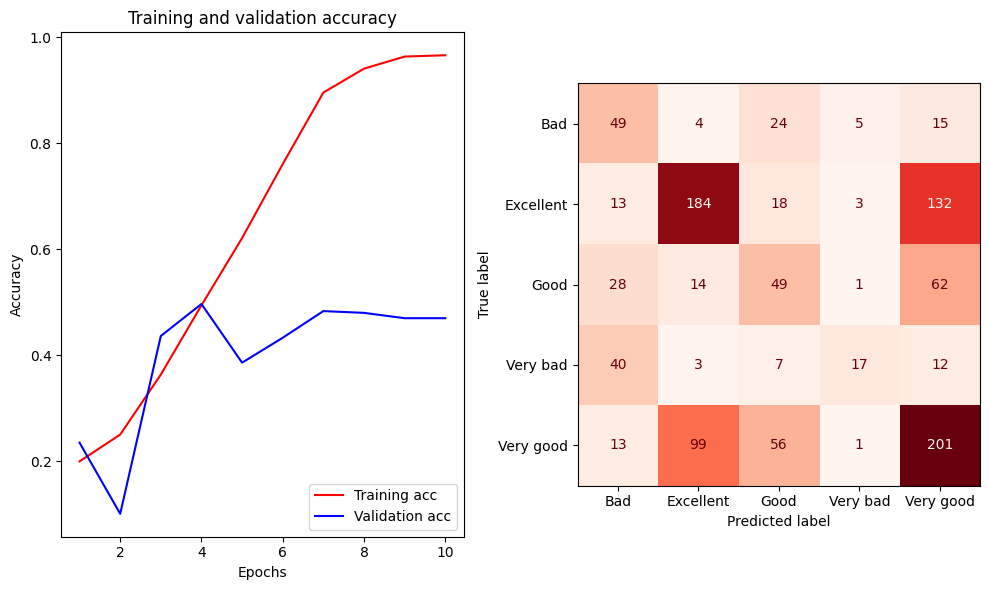

In [126]:
# Transformer Model

class MultiHeadSelfAttention(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.embed_dim = embed_dim
        self.projection_dim = embed_dim // num_heads

        self.query = tf.keras.layers.Dense(embed_dim)
        self.key = tf.keras.layers.Dense(embed_dim)
        self.value = tf.keras.layers.Dense(embed_dim)
        self.combine_heads = tf.keras.layers.Dense(embed_dim)

    def attention(self, query, key, value):
        scores = tf.matmul(query, key, transpose_b=True)
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32)
        scaled_scores = scores / tf.math.sqrt(dim_key)
        weights = tf.nn.softmax(scaled_scores, axis=-1)
        return tf.matmul(weights, value)

    def separate_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]

        query = self.separate_heads(self.query(inputs), batch_size)
        key = self.separate_heads(self.key(inputs), batch_size)
        value = self.separate_heads(self.value(inputs), batch_size)

        attention_output = self.attention(query, key, value)
        attention_output = tf.transpose(attention_output, perm=[0, 2, 1, 3])

        concat_output = tf.reshape(attention_output, (batch_size, -1, self.embed_dim))
        return self.combine_heads(concat_output)

class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = MultiHeadSelfAttention(embed_dim, num_heads)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim),
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(self, inputs, training=False):
        att_output = self.att(inputs)
        att_output = self.dropout1(att_output, training=training)
        out1 = self.layernorm1(inputs + att_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, max_len, embed_dim):
        super().__init__()
        self.pos_embedding = tf.keras.layers.Embedding(input_dim=max_len, output_dim=embed_dim)

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[1], delta=1)
        positions = self.pos_embedding(positions)
        return x + positions

def build_transformer_classifier(
        vocab_size,
        max_len,
        embed_dim=64,
        num_heads=4,
        ff_dim=128,
        num_blocks=2):

    inputs = tf.keras.layers.Input(shape=(), dtype=tf.string)  # rank-1 string input

    # Vectorize strings into integer sequences of length max_len
    x = text_vec_layer(inputs)

    x = tf.keras.layers.Embedding(vocab_size, embed_dim)(x)
    x = PositionalEncoding(max_len, embed_dim)(x)

    for _ in range(num_blocks):
        x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_transformer_classifier(VOCAB_SIZE, MAX_SEQUENCE_LENGTH)
history = model.fit(
    X_train_cleaned,
    y_train,
    validation_data=(X_validation_cleaned, y_validation),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr],
    verbose=2,
)
evaluate_model(model, history, X_test_cleaned, y_test)

In [127]:
MODEL = single_layer_model

MODEL.save('../models/tensorflow_model', save_format='tf')

INFO:tensorflow:Assets written to: tensorflow_model\assets


In [128]:
df_test = pd.read_csv('../data/test.csv')
df_test['text'] = df_test['text'].apply(lambda x: preprocess_text(x))

y_pred_probs = MODEL.predict(np.array(df_test['text']))
y_pred_indices = np.argmax(y_pred_probs, axis=1)
y_pred_labels = class_label_encoder.inverse_transform(y_pred_indices)

submission = pd.DataFrame({
    'id': df_test['id'],
    'review': y_pred_labels
})

submission_filepath = '../data/submission_' + MODEL.name + '.csv'
submission.to_csv(submission_filepath, index=False)

print(f"Saved submission '{submission_filepath}'")

94/94 [==============================] - 0s 3ms/step
Saved submission 'submission_single_layer_model.csv'
